# Práctica 7: detectar y corregir sesgo con Fairlearn

**Estudiante:** Marcos Devincenzi  
**Unidad:** UT2 — Calidad y Ética en Ingeniería de Datos

## Objetivos

- Detectar sesgo histórico en Boston Housing.
- Analizar brechas de género, clase e interseccionalidad en Titanic.
- Comparar un clasificador baseline con otro restringido por paridad demográfica.
- Aplicar el enfoque de detección a Ames Housing.
- Documentar los límites técnicos y las decisiones éticas.

> Uso exclusivamente educativo. Boston Housing contiene una variable racial históricamente problemática y no debe utilizarse para decisiones reales.

In [1]:
# === SETUP ===
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error
from sklearn.datasets import fetch_openml

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate,
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
np.random.seed(42)

print("✅ Entorno configurado")

✅ Entorno configurado


## Parte I — Boston Housing: detectar sesgo racial histórico

La fuente original de CMU indicada por la consigna actualmente responde con HTTP 403. Para conservar la reproducibilidad se utiliza una copia pública del mismo conjunto, con las 506 observaciones y las variables originales.

In [2]:
# === PASO 1 Y 2: CARGA Y VARIABLE PROBLEMÁTICA ===
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df = pd.read_csv(boston_url)
boston_df.columns = boston_df.columns.str.upper()

# Fórmula usada por la consigna: B = 1000(Bk - 0.63)^2.
boston_df["Bk_racial"] = np.sqrt(boston_df["B"] / 1000) + 0.63
boston_corr = boston_df["B"].corr(boston_df["MEDV"])

print(f"✅ Boston Housing: {boston_df.shape}")
print(f"Correlación B vs MEDV: {boston_corr:.3f}")
print(f"Proporción racial reconstruida media: {boston_df['Bk_racial'].mean():.3f}")
display(boston_df.head())

✅ Boston Housing: (506, 15)
Correlación B vs MEDV: 0.333
Proporción racial reconstruida media: 1.216


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,Bk_racial
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,1.260000
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,1.260000
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1.256762
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1.258196
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1.260000


In [3]:
# === PASO 3: BASELINE CON Y SIN VARIABLE B ===
X_with_bias = boston_df.drop(columns=["MEDV", "Bk_racial"])
X_without_bias = X_with_bias.drop(columns=["B"])
y_boston = boston_df["MEDV"]

train_idx, test_idx = train_test_split(
    np.arange(len(boston_df)), test_size=0.30, random_state=42
)

boston_biased_model = LinearRegression()
boston_biased_model.fit(X_with_bias.iloc[train_idx], y_boston.iloc[train_idx])
boston_biased_pred = boston_biased_model.predict(X_with_bias.iloc[test_idx])
boston_biased_r2 = r2_score(y_boston.iloc[test_idx], boston_biased_pred)

boston_without_b_model = LinearRegression()
boston_without_b_model.fit(X_without_bias.iloc[train_idx], y_boston.iloc[train_idx])
boston_without_b_pred = boston_without_b_model.predict(X_without_bias.iloc[test_idx])
boston_without_b_r2 = r2_score(y_boston.iloc[test_idx], boston_without_b_pred)

boston_performance_cost = boston_biased_r2 - boston_without_b_r2

print(f"R² con B: {boston_biased_r2:.4f}")
print(f"R² sin B: {boston_without_b_r2:.4f}")
print(f"Cambio de R² al eliminar B: {boston_performance_cost:+.4f}")

R² con B: 0.7112
R² sin B: 0.7166
Cambio de R² al eliminar B: -0.0054


,mean,median,std,count
grupo_racial,,,,
Alta_prop_afroam,22.811,22.0,7.995,253
Baja_prop_afroam,22.255,20.4,10.268,253


Brecha promedio: -0.56 miles de USD (-2.4%)


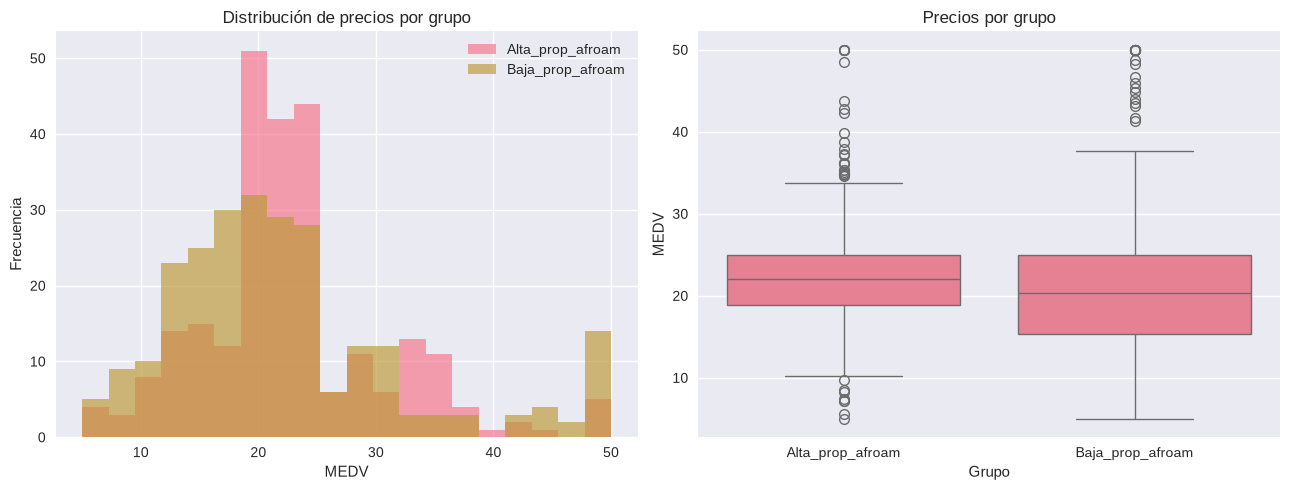

In [4]:
# === PASO 4: ANÁLISIS DE BRECHA ===
racial_threshold = boston_df["Bk_racial"].median()
boston_df["grupo_racial"] = (
    boston_df["Bk_racial"] > racial_threshold
).map({True: "Alta_prop_afroam", False: "Baja_prop_afroam"})

price_by_group = boston_df.groupby("grupo_racial")["MEDV"].agg(
    ["mean", "median", "std", "count"]
)
price_gap = (
    price_by_group.loc["Baja_prop_afroam", "mean"]
    - price_by_group.loc["Alta_prop_afroam", "mean"]
)
price_gap_pct = price_gap / price_by_group.loc["Alta_prop_afroam", "mean"] * 100

display(price_by_group.round(3))
print(f"Brecha promedio: {price_gap:.2f} miles de USD ({price_gap_pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for group in boston_df["grupo_racial"].unique():
    values = boston_df.loc[boston_df["grupo_racial"] == group, "MEDV"]
    axes[0].hist(values, alpha=0.65, label=group, bins=20)
axes[0].set(title="Distribución de precios por grupo", xlabel="MEDV", ylabel="Frecuencia")
axes[0].legend()
sns.boxplot(data=boston_df, x="grupo_racial", y="MEDV", ax=axes[1])
axes[1].set(title="Precios por grupo", xlabel="Grupo", ylabel="MEDV")
plt.tight_layout()
plt.show()

### Paso 5 — Decisión ética sobre Boston

La variable `B` no debería utilizarse en un sistema de producción que afecte decisiones inmobiliarias, crediticias o sobre personas. Aunque pueda aportar señal predictiva, codifica una característica racial mediante una fórmula cuestionable y puede perpetuar desigualdades históricas. Eliminarla tampoco garantiza equidad porque otras variables, como criminalidad, ubicación o nivel socioeconómico, pueden funcionar como proxies.

**Decisión:** utilizar Boston Housing solamente con fines educativos para estudiar sesgos, documentando explícitamente su origen y sus limitaciones. Para un proyecto real usaría datos contemporáneos, una definición legítima del objetivo, evaluación por grupos y revisión con especialistas del dominio.

## Parte II — Titanic: detectar y corregir sesgo por género y clase

✅ Titanic limpio: (712, 12)
Brecha de supervivencia por género: 54.8%
Brecha entre primera y tercera clase: 41.3%


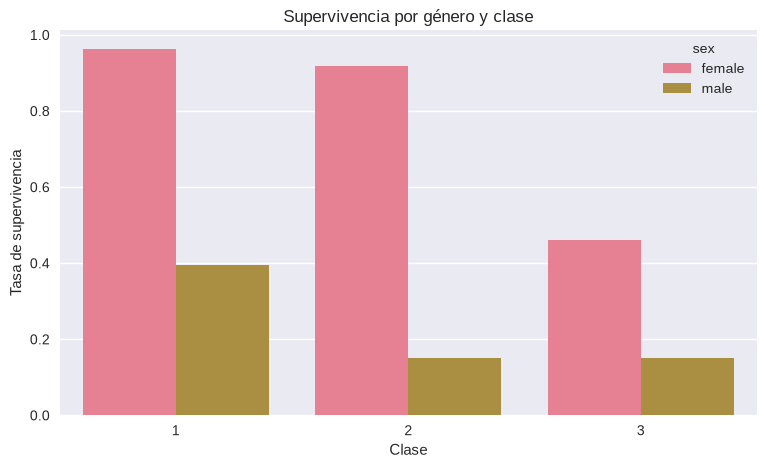

In [5]:
# === PASO 6: CARGA Y ANÁLISIS DESCRIPTIVO ===
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(titanic_url)
titanic.columns = titanic.columns.str.lower()
titanic_clean = titanic.dropna(subset=["age", "embarked"]).copy()

gender_survival = titanic_clean.groupby("sex")["survived"].mean()
class_survival = titanic_clean.groupby("pclass")["survived"].mean()
intersectional_survival = titanic_clean.groupby(["sex", "pclass"])["survived"].agg(
    ["mean", "count"]
)

titanic_gender_gap = gender_survival["female"] - gender_survival["male"]
titanic_class_gap = class_survival.loc[1] - class_survival.loc[3]

print(f"✅ Titanic limpio: {titanic_clean.shape}")
print(f"Brecha de supervivencia por género: {titanic_gender_gap:.1%}")
print(f"Brecha entre primera y tercera clase: {titanic_class_gap:.1%}")
display(intersectional_survival.style.format({"mean": "{:.1%}"}))

plt.figure(figsize=(9, 5))
sns.barplot(data=titanic_clean, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Supervivencia por género y clase")
plt.xlabel("Clase")
plt.ylabel("Tasa de supervivencia")
plt.show()

In [6]:
# === PASO 7: MODELO BASELINE ===
features_titanic = ["pclass", "age", "sibsp", "parch", "fare"]
X_titanic = titanic_clean[features_titanic].copy()
X_titanic["fare"] = X_titanic["fare"].fillna(X_titanic["fare"].median())
y_titanic = titanic_clean["survived"]
sensitive_titanic = titanic_clean["sex"]

X_train_t, X_test_t, y_train_t, y_test_t, A_train_t, A_test_t = train_test_split(
    X_titanic,
    y_titanic,
    sensitive_titanic,
    test_size=0.30,
    random_state=42,
    stratify=y_titanic,
)

titanic_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
titanic_baseline.fit(X_train_t, y_train_t)
titanic_baseline_pred = titanic_baseline.predict(X_test_t)

titanic_baseline_acc = accuracy_score(y_test_t, titanic_baseline_pred)
titanic_baseline_dp = demographic_parity_difference(
    y_test_t, titanic_baseline_pred, sensitive_features=A_test_t
)
titanic_baseline_eo = equalized_odds_difference(
    y_test_t, titanic_baseline_pred, sensitive_features=A_test_t
)

baseline_frame = MetricFrame(
    metrics={"accuracy": accuracy_score, "selection_rate": selection_rate},
    y_true=y_test_t,
    y_pred=titanic_baseline_pred,
    sensitive_features=A_test_t,
)

print(f"Baseline accuracy: {titanic_baseline_acc:.3f}")
print(f"Demographic parity difference: {titanic_baseline_dp:.3f}")
print(f"Equalized odds difference: {titanic_baseline_eo:.3f}")
display(baseline_frame.by_group)

Baseline accuracy: 0.673
Demographic parity difference: 0.113
Equalized odds difference: 0.240


,accuracy,selection_rate
sex,,
female,0.682927,0.439024
male,0.666667,0.325758


In [7]:
# === PASO 8: MODELO CON RESTRICCIÓN DE FAIRLEARN ===
titanic_fair = ExponentiatedGradient(
    RandomForestClassifier(n_estimators=100, random_state=42),
    constraints=DemographicParity(),
    sample_weight_name="sample_weight",
)
titanic_fair.fit(X_train_t, y_train_t, sensitive_features=A_train_t)
titanic_fair_pred = titanic_fair.predict(X_test_t, random_state=42)

titanic_fair_acc = accuracy_score(y_test_t, titanic_fair_pred)
titanic_fair_dp = demographic_parity_difference(
    y_test_t, titanic_fair_pred, sensitive_features=A_test_t
)
titanic_fair_eo = equalized_odds_difference(
    y_test_t, titanic_fair_pred, sensitive_features=A_test_t
)

fair_frame = MetricFrame(
    metrics={"accuracy": accuracy_score, "selection_rate": selection_rate},
    y_true=y_test_t,
    y_pred=titanic_fair_pred,
    sensitive_features=A_test_t,
)

print(f"Fair accuracy: {titanic_fair_acc:.3f}")
print(f"Demographic parity difference: {titanic_fair_dp:.3f}")
print(f"Equalized odds difference: {titanic_fair_eo:.3f}")
display(fair_frame.by_group)

Fair accuracy: 0.621
Demographic parity difference: 0.026
Equalized odds difference: 0.162


,accuracy,selection_rate
sex,,
female,0.439024,0.170732
male,0.734848,0.196970


,Modelo,Accuracy,DP difference (abs),EO difference (abs)
0,Baseline,0.673,0.113,0.240
1,Fairlearn,0.621,0.026,0.162


Pérdida relativa de accuracy: 7.6%
Ganancia en paridad demográfica: 0.087
Recomendación: Evaluar el caso y otras restricciones antes de desplegar.


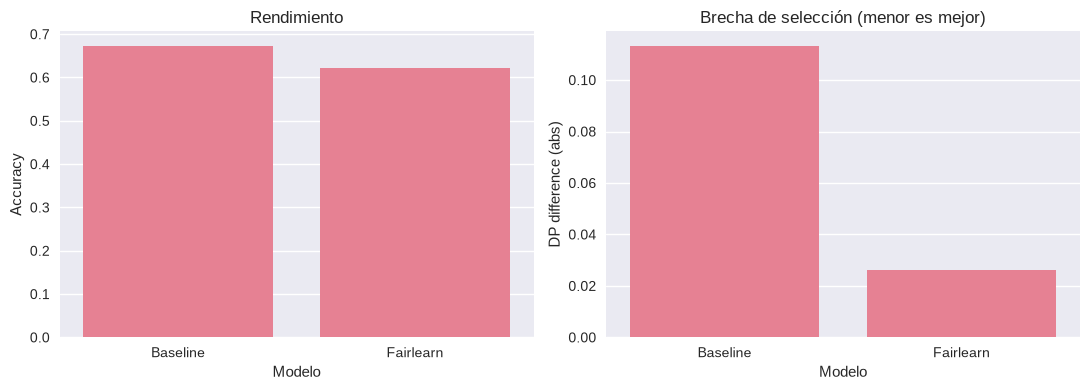

In [8]:
# === PASO 9: ANÁLISIS DEL TRADE-OFF ===
titanic_performance_loss = (
    (titanic_baseline_acc - titanic_fair_acc) / titanic_baseline_acc * 100
)
titanic_fairness_gain = abs(titanic_baseline_dp) - abs(titanic_fair_dp)

if titanic_performance_loss < 5 and titanic_fairness_gain > 0.1:
    titanic_recommendation = "Usar el modelo restringido: el trade-off medido es favorable."
else:
    titanic_recommendation = "Evaluar el caso y otras restricciones antes de desplegar."

tradeoff = pd.DataFrame(
    {
        "Modelo": ["Baseline", "Fairlearn"],
        "Accuracy": [titanic_baseline_acc, titanic_fair_acc],
        "DP difference (abs)": [abs(titanic_baseline_dp), abs(titanic_fair_dp)],
        "EO difference (abs)": [abs(titanic_baseline_eo), abs(titanic_fair_eo)],
    }
)
display(tradeoff.round(3))
print(f"Pérdida relativa de accuracy: {titanic_performance_loss:.1f}%")
print(f"Ganancia en paridad demográfica: {titanic_fairness_gain:.3f}")
print(f"Recomendación: {titanic_recommendation}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=tradeoff, x="Modelo", y="Accuracy", ax=axes[0])
sns.barplot(data=tradeoff, x="Modelo", y="DP difference (abs)", ax=axes[1])
axes[0].set_title("Rendimiento")
axes[1].set_title("Brecha de selección (menor es mejor)")
plt.tight_layout()
plt.show()

### Interpretación ética de Titanic

La diferencia histórica de supervivencia no representa una decisión justa contemporánea: surge del contexto del naufragio y del protocolo aplicado. La paridad demográfica reduce diferencias en la tasa de predicciones positivas, pero no garantiza por sí sola igualdad de errores ni justicia. Por eso se reportan también métricas por grupo y `equalized odds`, y la decisión final debe considerar el propósito y el daño potencial del sistema.

## Parte III — Ames Housing: sesgo geográfico y temporal

Se utiliza Ames Housing desde OpenML. `Neighborhood` se trata como señal geográfica sensible y `YearBuilt` permite comparar viviendas antiguas y nuevas. El objetivo es detectar brechas y errores por grupo, no afirmar que las diferencias sean causales.

In [9]:
# === CARGA Y GRUPOS SENSIBLES DE AMES ===
ames = fetch_openml(name="house_prices", as_frame=True)
ames_df = ames.frame.copy()
ames_df["SalePrice"] = pd.to_numeric(ames_df["SalePrice"], errors="coerce")

neighborhood_prices = ames_df.groupby("Neighborhood")["SalePrice"].mean()
neighborhood_threshold = neighborhood_prices.median()
ames_df["grupo_geografico"] = ames_df["Neighborhood"].map(
    (neighborhood_prices >= neighborhood_threshold).map(
        {True: "Barrios_precio_alto", False: "Barrios_precio_bajo"}
    )
)
year_threshold = ames_df["YearBuilt"].median()
ames_df["grupo_temporal"] = np.where(
    ames_df["YearBuilt"] >= year_threshold, "Vivienda_nueva", "Vivienda_antigua"
)

ames_geo_stats = ames_df.groupby("grupo_geografico")["SalePrice"].agg(
    ["mean", "median", "count"]
)
ames_time_stats = ames_df.groupby("grupo_temporal")["SalePrice"].agg(
    ["mean", "median", "count"]
)

ames_geo_gap_pct = (
    (ames_geo_stats.loc["Barrios_precio_alto", "mean"]
     - ames_geo_stats.loc["Barrios_precio_bajo", "mean"])
    / ames_geo_stats.loc["Barrios_precio_bajo", "mean"] * 100
)
ames_time_gap_pct = (
    (ames_time_stats.loc["Vivienda_nueva", "mean"]
     - ames_time_stats.loc["Vivienda_antigua", "mean"])
    / ames_time_stats.loc["Vivienda_antigua", "mean"] * 100
)

print(f"✅ Ames Housing: {ames_df.shape}")
display(ames_geo_stats.round(2))
display(ames_time_stats.round(2))
print(f"Brecha geográfica de precio: {ames_geo_gap_pct:.1f}%")
print(f"Brecha temporal de precio: {ames_time_gap_pct:.1f}%")

✅ Ames Housing: (1460, 83)


,mean,median,count
grupo_geografico,,,
Barrios_precio_alto,226967.76,207000.0,735
Barrios_precio_bajo,134239.50,132000.0,725


,mean,median,count
grupo_temporal,,,
Vivienda_antigua,139762.33,134000.0,729
Vivienda_nueva,221967.46,200000.0,731


Brecha geográfica de precio: 69.1%
Brecha temporal de precio: 58.8%


RMSE general: USD 28,364
RMSE por grupo geográfico:


grupo_geografico
Barrios_precio_alto    33566.0
Barrios_precio_bajo    21839.0
Name: squared_error, dtype: float64

RMSE por grupo temporal:


grupo_temporal
Vivienda_antigua    25480.0
Vivienda_nueva      30886.0
Name: squared_error, dtype: float64

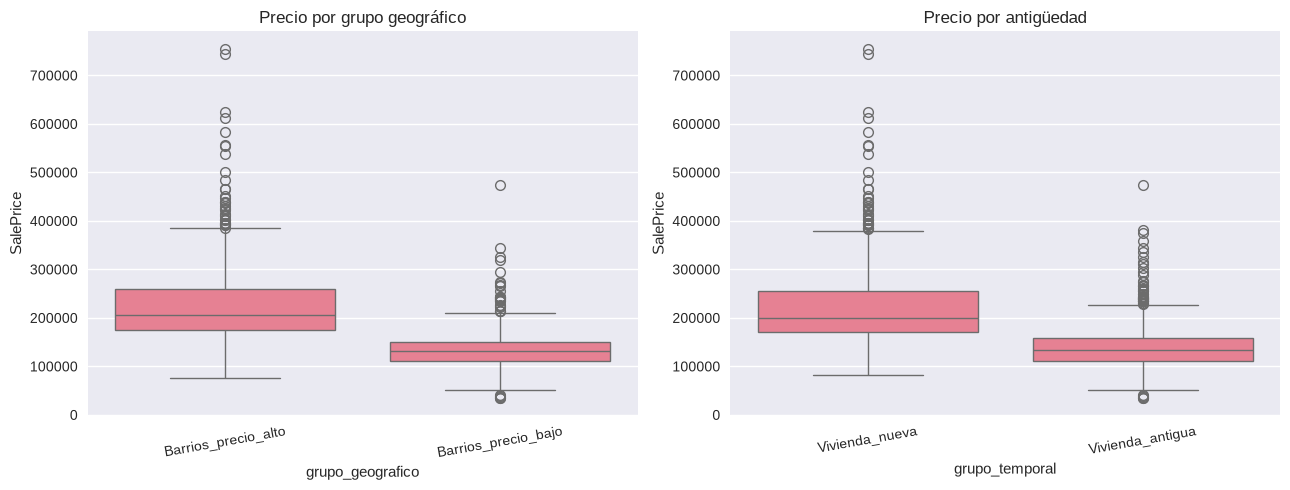

In [10]:
# === MODELO Y ERROR POR GRUPOS EN AMES ===
ames_features = [
    "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "YearBuilt"
]
ames_model_df = ames_df[
    ames_features + ["SalePrice", "grupo_geografico", "grupo_temporal"]
].copy()
for col in ames_features:
    ames_model_df[col] = pd.to_numeric(ames_model_df[col], errors="coerce")
    ames_model_df[col] = ames_model_df[col].fillna(ames_model_df[col].median())
ames_model_df = ames_model_df.dropna(subset=["SalePrice"])

train_a, test_a = train_test_split(ames_model_df, test_size=0.25, random_state=42)
ames_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
ames_model.fit(train_a[ames_features], train_a["SalePrice"])
ames_pred = ames_model.predict(test_a[ames_features])
ames_rmse = np.sqrt(mean_squared_error(test_a["SalePrice"], ames_pred))

ames_errors = test_a[["grupo_geografico", "grupo_temporal", "SalePrice"]].copy()
ames_errors["prediction"] = ames_pred
ames_errors["squared_error"] = (ames_errors["SalePrice"] - ames_errors["prediction"]) ** 2

ames_geo_rmse = ames_errors.groupby("grupo_geografico")["squared_error"].mean().pow(0.5)
ames_time_rmse = ames_errors.groupby("grupo_temporal")["squared_error"].mean().pow(0.5)

print(f"RMSE general: USD {ames_rmse:,.0f}")
print("RMSE por grupo geográfico:")
display(ames_geo_rmse.round(0))
print("RMSE por grupo temporal:")
display(ames_time_rmse.round(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=ames_df, x="grupo_geografico", y="SalePrice", ax=axes[0])
sns.boxplot(data=ames_df, x="grupo_temporal", y="SalePrice", ax=axes[1])
axes[0].set_title("Precio por grupo geográfico")
axes[1].set_title("Precio por antigüedad")
for ax in axes:
    ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.show()

### Decisión ética sobre Ames

No desplegaría este modelo directamente para conceder hipotecas, fijar límites crediticios o tomar decisiones que afecten el acceso a vivienda. `Neighborhood` y `YearBuilt` pueden actuar como proxies de condiciones socioeconómicas e históricas. Antes de un uso real exigiría datos representativos y recientes, métricas de error por grupos, análisis de variables proxy, revisión legal, explicación de decisiones, supervisión humana y un mecanismo de apelación.

In [11]:
# === ENTREGA FINAL: RESULTADOS CONSOLIDADOS ===
final_results = pd.DataFrame(
    [
        {
            "Caso": "Boston Housing",
            "Brecha principal": f"{price_gap_pct:.1f}% en MEDV medio",
            "Resultado modelo": f"R² con B {boston_biased_r2:.3f}; sin B {boston_without_b_r2:.3f}",
            "Decisión": "Solo educación; no producción",
        },
        {
            "Caso": "Titanic",
            "Brecha principal": f"{titanic_gender_gap:.1%} por género",
            "Resultado modelo": f"Pérdida accuracy {titanic_performance_loss:.1f}%; ganancia DP {titanic_fairness_gain:.3f}",
            "Decisión": titanic_recommendation,
        },
        {
            "Caso": "Ames Housing",
            "Brecha principal": f"{ames_geo_gap_pct:.1f}% geográfica; {ames_time_gap_pct:.1f}% temporal",
            "Resultado modelo": f"RMSE general USD {ames_rmse:,.0f}",
            "Decisión": "No usar en decisiones hipotecarias sin controles",
        },
    ]
)
display(final_results)

,Caso,Brecha principal,Resultado modelo,Decisión
0,Boston Housing,-2.4% en MEDV medio,R² con B 0.711; sin B 0.717,Solo educación; no producción
1,Titanic,54.8% por género,Pérdida accuracy 7.6%; ganancia DP 0.087,Evaluar el caso y otras restricciones antes de...
2,Ames Housing,69.1% geográfica; 58.8% temporal,"RMSE general USD 28,364",No usar en decisiones hipotecarias sin controles


## Reflexiones éticas finales

### ¿Cuándo es más valioso detectar que corregir automáticamente?

Cuando el sesgo proviene de procesos históricos complejos, las variables sensibles tienen proxies o no existe una definición consensuada de equidad. Una corrección automática puede ocultar el problema sin resolver su causa.

### ¿Cómo balancear transparencia y utilidad cuando persiste el sesgo?

Hay que publicar métricas generales y por grupo, explicar qué restricción se eligió, cuantificar el costo de rendimiento y definir límites de uso. La utilidad no justifica ocultar daños previsibles.

### ¿Qué responsabilidades existen frente a sesgos históricos?

Documentar procedencia y limitaciones, consultar a personas afectadas y especialistas, evitar usos de alto impacto sin garantías, monitorear resultados y ofrecer revisión humana y apelación.

### ¿Es mejor un modelo con sesgo conocido que uno “corregido” pero impredecible?

Ninguno es automáticamente aceptable. Un sesgo conocido permite medir el riesgo, pero no legitima el uso. Una corrección opaca también puede generar daños nuevos. La decisión debe basarse en pruebas por grupo, explicabilidad, impacto y capacidad de supervisión.

### ¿Cómo decidir sobre el deployment cuando el sesgo es inevitable?

Primero se evalúa la gravedad y reversibilidad del daño. En contextos de alto impacto, un sesgo relevante no mitigado debe bloquear el despliegue. En contextos de bajo riesgo pueden aplicarse límites, monitoreo, intervención humana y criterios de retiro.